Using device: cuda
LOADING SAVED TRAINING HISTORY
 Training history loaded successfully!
   Saved on: 2026-03-19 08:34:01
   Epochs: 15

TRAINING HISTORY SUMMARY


,Epoch,Model1_Train_Loss,Model1_Train_Acc,Model1_Test_Acc,Model2_Train_Loss,Model2_Train_Acc,Model2_Test_Acc,Model3_Train_Loss,Model3_Train_Acc,Model3_Test_Acc
0,1,0.533180,84.713131,81.380608,0.943692,70.729399,75.944991,0.350684,89.354355,93.419637
1,2,0.377559,89.685268,83.001690,0.716422,78.952262,79.333128,0.180560,95.005857,94.614321
2,3,0.345604,90.664110,81.538107,0.668978,80.509540,79.859404,0.142105,96.236027,94.806392
3,4,0.327486,91.174874,84.676552,0.631095,81.854206,80.977259,0.120069,96.883459,95.305778
4,5,0.315424,91.479480,84.918562,0.603455,82.750816,81.261524,0.104974,97.297431,95.497849
5,6,0.303771,91.837859,84.542102,0.576517,83.582566,82.652120,0.093531,97.568118,95.751383
6,7,0.298016,91.987432,84.918562,0.558122,84.157859,83.539490,0.084731,97.792643,95.778273
7,8,0.290550,92.220229,84.676552,0.543063,84.567860,83.896742,0.077867,97.974811,96.031807
8,9,0.286403,92.319669,85.398740,0.534995,84.804960,83.270590,0.071527,98.110485,96.108636
9,10,0.282099,92.481982,86.516595,0.531480,84.891659,79.763368,0.065913,98.236729,96.135526



FINAL EPOCH RESULTS


,Model,Final Train Loss,Final Train Acc,Final Test Acc
0,Baseline MLP,0.2647,92.97%,86.45%
1,Improved MLP,0.4980,85.91%,84.96%
2,CNN,0.0482,98.65%,96.06%


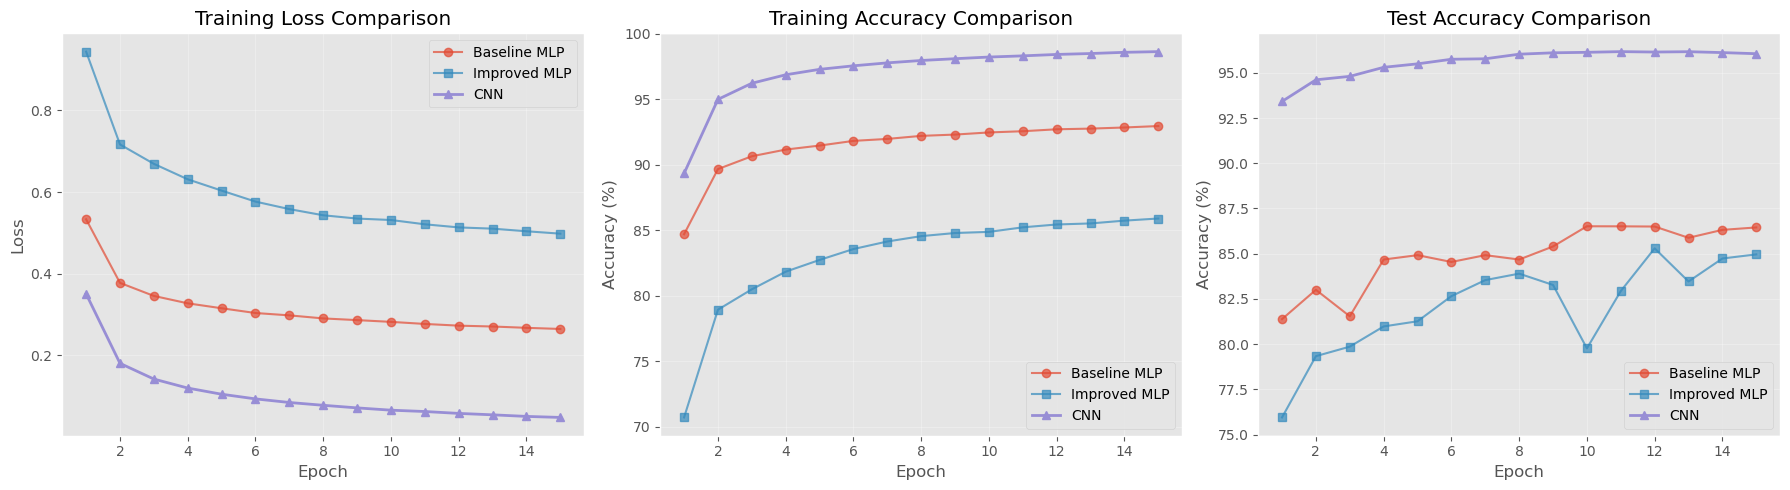


 Done! You can now see all training metrics without retraining.


In [13]:
# ==================== Simple Demo to Load Saved Models and Training History ====================
# Run this in a new ipynb file

import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# ==================== Setup ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

SAVE_DIR = Path('saved_models')
if not SAVE_DIR.exists():
    raise Exception(" saved_models folder not found!")

# ==================== Redefine Model Architectures (Must match training) ====================
class BaselineMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class ImprovedMLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(32*32*3, 1024),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.01),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# ==================== Load Training History ====================
def load_training_history():
    history_path = SAVE_DIR / 'training_history.pkl'
    if history_path.exists():
        with open(history_path, 'rb') as f:
            history = pickle.load(f)
        print(f" Training history loaded successfully!")
        print(f"   Saved on: {history['metadata']['saved_date']}")
        print(f"   Epochs: {history['metadata']['epochs']}")
        return history
    else:
        print(" Training history file not found")
        return None

# ==================== Display Training History ====================
def display_training_history(history):
    """Display the saved training metrics"""
    if history is None:
        return
    
    print("\n" + "="*60)
    print("TRAINING HISTORY SUMMARY")
    print("="*60)
    
    # Create DataFrame from history
    data = {
        'Epoch': list(range(1, history['metadata']['epochs'] + 1)),
        'Model1_Train_Loss': history['model1']['train_loss'],
        'Model1_Train_Acc': history['model1']['train_acc'],
        'Model1_Test_Acc': history['model1']['test_acc'],
        'Model2_Train_Loss': history['model2']['train_loss'],
        'Model2_Train_Acc': history['model2']['train_acc'],
        'Model2_Test_Acc': history['model2']['test_acc'],
        'Model3_Train_Loss': history['model3']['train_loss'],
        'Model3_Train_Acc': history['model3']['train_acc'],
        'Model3_Test_Acc': history['model3']['test_acc'],
    }
    
    df = pd.DataFrame(data)
    display(df)
    
    # Final epoch summary
    print("\n" + "="*60)
    print("FINAL EPOCH RESULTS")
    print("="*60)
    
    final_results = pd.DataFrame({
        'Model': ['Baseline MLP', 'Improved MLP', 'CNN'],
        'Final Train Loss': [
            f"{history['model1']['train_loss'][-1]:.4f}",
            f"{history['model2']['train_loss'][-1]:.4f}",
            f"{history['model3']['train_loss'][-1]:.4f}"
        ],
        'Final Train Acc': [
            f"{history['model1']['train_acc'][-1]:.2f}%",
            f"{history['model2']['train_acc'][-1]:.2f}%",
            f"{history['model3']['train_acc'][-1]:.2f}%"
        ],
        'Final Test Acc': [
            f"{history['model1']['test_acc'][-1]:.2f}%",
            f"{history['model2']['test_acc'][-1]:.2f}%",
            f"{history['model3']['test_acc'][-1]:.2f}%"
        ]
    })
    
    display(final_results)

# ==================== Visualize Training History ====================
def plot_training_history(history):
    """Plot training curves"""
    if history is None:
        return
    
    m1 = history['model1']
    m2 = history['model2']
    m3 = history['model3']
    epochs = history['metadata']['epochs']
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 1. Training Loss
    ax = axes[0]
    ax.plot(range(1, epochs+1), m1['train_loss'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_loss'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_loss'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Loss Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Training Accuracy
    ax = axes[1]
    ax.plot(range(1, epochs+1), m1['train_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['train_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['train_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Training Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Test Accuracy
    ax = axes[2]
    ax.plot(range(1, epochs+1), m1['test_acc'], 'o-', label='Baseline MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m2['test_acc'], 's-', label='Improved MLP', alpha=0.7)
    ax.plot(range(1, epochs+1), m3['test_acc'], '^-', label='CNN', linewidth=2)
    ax.set_title('Test Accuracy Comparison')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# ==================== Main ====================
def main():
    print("="*60)
    print("LOADING SAVED TRAINING HISTORY")
    print("="*60)
    
    # Load history
    history = load_training_history()
    
    if history:
        # Display numerical data
        display_training_history(history)
        
        # Plot curves
        plot_training_history(history)
        
        print("\n Done! You can now see all training metrics without retraining.")
    else:
        print("\n No training history found. Please train the models first.")

# Run
if __name__ == "__main__":
    main()

# Prepare data

In [2]:
import torch
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, ConcatDataset

print("正在加载 SVHN cropped 数据集...")

# ==================== 数据预处理 ====================
transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)),
    ]
)

# ==================== 加载数据集 ====================
root_path = "./svhn_cropped"  

train_set = torchvision.datasets.SVHN(
    root=root_path, split="train", download=False, transform=transform
)

test_set = torchvision.datasets.SVHN(
    root=root_path, split="test", download=False, transform=transform
)

# 加 extra（53万张免费数据，强烈建议！）
extra_set = torchvision.datasets.SVHN(
    root=root_path, split="extra", download=False, transform=transform
)

full_train_set = ConcatDataset([train_set, extra_set])

# ==================== DataLoader ====================
train_loader = DataLoader(
    full_train_set, batch_size=128, shuffle=True, num_workers=4, pin_memory=True
)

test_loader = DataLoader(
    test_set, batch_size=128, shuffle=False, num_workers=4, pin_memory=True
)

print(f"加载完成！")
print(f"训练集大小: {len(full_train_set):,} 张 (train + extra)")
print(f"测试集大小: {len(test_set):,} 张")

正在加载 SVHN cropped 数据集...
加载完成！
训练集大小: 604,388 张 (train + extra)
测试集大小: 26,032 张


# Hyperparameter Tuning

In [3]:
!pip install optuna -q

In [4]:


import optuna
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import copy
print(f"Optuna version: {optuna.__version__}")

Optuna version: 4.8.0


# 第二步：可调参的 ImprovedMLP（基于你 Model 2） 

In [5]:

class TunableMLP(nn.Module):
    def __init__(self, hidden_sizes=[1024, 512, 256], dropout=0.5, activation=nn.LeakyReLU(0.01)):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        in_features = 32 * 32 * 3
        
        for h in hidden_sizes:
            layers.append(nn.Linear(in_features, h))
            layers.append(copy.deepcopy(activation))
            layers.append(nn.Dropout(dropout))
            in_features = h
        
        layers.append(nn.Linear(in_features, 10))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

# 第三步：Optuna 目标函数（Bayesian Optimization 核心）



In [6]:

def objective(trial):
    # ----- Bayesian 
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.7)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)
    batch_size = trial.suggest_categorical("batch_size", [64, 128, 256, 512])
    hidden1 = trial.suggest_categorical("hidden1", [512, 1024, 2048])
    hidden2 = trial.suggest_categorical("hidden2", [256, 512, 1024])
    
    # 根据 batch_size 动态创建 DataLoader 
    train_loader_tune = DataLoader(
        full_train_set,
        batch_size=batch_size,
        shuffle=True,
        num_workers=4,
        pin_memory=True
    )
    
    # 创建模型
    model = TunableMLP(
        hidden_sizes=[hidden1, hidden2],
        dropout=dropout
    ).to(device)
    
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.CrossEntropyLoss()
    
    # 快速评估（epoch = 8）
    for epoch in range(8):
        model.train()
        for images, labels in train_loader_tune:   # tqdm 会让界面太乱，这里省略
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
    
    # 测试准确率 
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    accuracy = correct / total
    return accuracy

# 第四步：运行 Bayesian Optimization

[I 2026-03-23 15:25:59,279] A new study created in memory with name: no-name-630db6c4-f228-4c1f-835f-c7fcc411be84


开始 Bayesian Optimization（TPE）...


[I 2026-03-23 15:34:21,137] Trial 0 finished with value: 0.8338583282114321 and parameters: {'lr': 0.0001329291894316216, 'dropout': 0.6704285838459496, 'weight_decay': 0.000157029708840554, 'batch_size': 64, 'hidden1': 512, 'hidden2': 512}. Best is trial 0 with value: 0.8338583282114321.
[I 2026-03-23 15:41:45,743] Trial 1 finished with value: 0.8847572218807621 and parameters: {'lr': 4.335281794951564e-05, 'dropout': 0.20909498032426038, 'weight_decay': 3.549878832196506e-06, 'batch_size': 128, 'hidden1': 512, 'hidden2': 1024}. Best is trial 1 with value: 0.8847572218807621.
[I 2026-03-23 15:49:13,602] Trial 2 finished with value: 0.8827980946527351 and parameters: {'lr': 3.972110727381908e-05, 'dropout': 0.40854066304816694, 'weight_decay': 5.987474910461405e-05, 'batch_size': 128, 'hidden1': 1024, 'hidden2': 1024}. Best is trial 1 with value: 0.8847572218807621.
[I 2026-03-23 15:56:43,287] Trial 3 finished with value: 0.8866011063306699 and parameters: {'lr': 0.00020914981329035596


 Bayesian Optimization 完成！
Best Accuracy: 0.9023
Best Hyperparameters:
  lr: 0.00010776771579408408
  dropout: 0.3098332393496424
  weight_decay: 8.643215600464267e-06
  batch_size: 128
  hidden1: 2048
  hidden2: 1024


/tmp/ipykernel_29890/2041144954.py:21: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


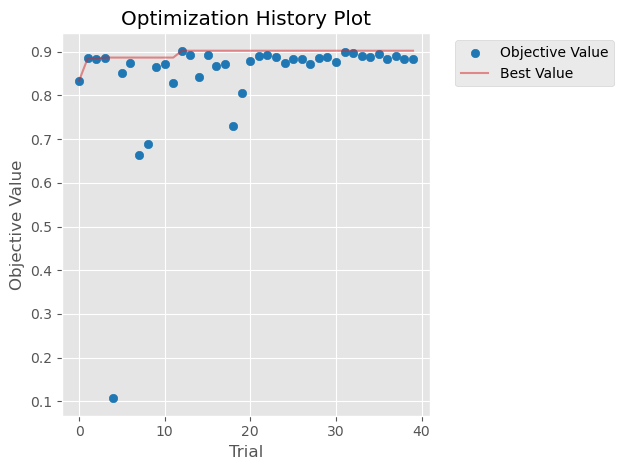

/tmp/ipykernel_29890/2041144954.py:24: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


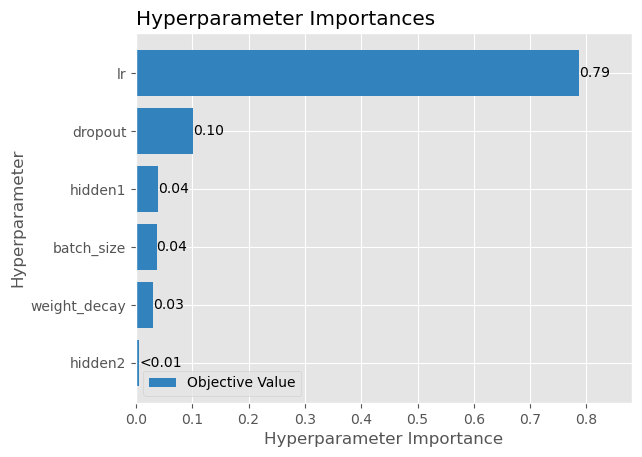

In [7]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),   # TPE = Bayesian Optimization
    pruner=optuna.pruners.MedianPruner()           # 自动剪掉差的试验，节省时间
)

print("开始 Bayesian Optimization（TPE）...")
# study.optimize(objective, n_trials=40, timeout=3600*2)   # 40 次试验 或 2 小时上限
study.optimize(objective, n_trials=40)

#显示最佳结果
print("\n Bayesian Optimization 完成！")
print(f"Best Accuracy: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

# 可视化优化过程
optuna.visualization.matplotlib.plot_optimization_history(study)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study)
plt.show()

# 第五步：用最佳参数重新完整训练（15-20 epochs）

In [8]:

best_params = study.best_params

# 最终 DataLoader
final_train_loader = DataLoader(
    full_train_set,
    batch_size=best_params["batch_size"],
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

final_model = TunableMLP(
    hidden_sizes=[best_params["hidden1"], best_params["hidden2"]],
    dropout=best_params["dropout"]
).to(device)

optimizer = optim.Adam(
    final_model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)
criterion = nn.CrossEntropyLoss()

# 完整训练（和之前 Model 1/2 一样的循环）
train_loss_list_final = []
test_acc_list_final = []
epochs_final = 20

print("用最佳参数完整训练最终模型...")

for epoch in range(epochs_final):
    final_model.train()
    running_loss = 0.0
    for images, labels in tqdm(final_train_loader, desc=f"Final Epoch {epoch+1}"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = final_model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    
    avg_loss = running_loss / len(final_train_loader)
    train_loss_list_final.append(avg_loss)
    
    # Test
    final_model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = final_model(images)
            _, pred = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (pred == labels).sum().item()
    
    acc = 100 * correct / total
    test_acc_list_final.append(acc)
    
    print(f"Epoch {epoch+1:2d} | Loss: {avg_loss:.4f} | Test Acc: {acc:.2f}%")

print(f"最终 Test Accuracy: {test_acc_list_final[-1]:.2f}%")

用最佳参数完整训练最终模型...


Final Epoch 1: 100%|██████████| 4722/4722 [00:57<00:00, 82.34it/s]


Epoch  1 | Loss: 0.5784 | Test Acc: 83.38%


Final Epoch 2: 100%|██████████| 4722/4722 [00:57<00:00, 81.46it/s]


Epoch  2 | Loss: 0.3557 | Test Acc: 85.13%


...

Epoch 18 | Loss: 0.1609 | Test Acc: 91.40%


Final Epoch 19: 100%|██████████| 4722/4722 [00:57<00:00, 82.43it/s]


Epoch 19 | Loss: 0.1579 | Test Acc: 91.44%


Final Epoch 20: 100%|██████████| 4722/4722 [00:58<00:00, 81.39it/s]


Epoch 20 | Loss: 0.1551 | Test Acc: 90.97%
最终 Test Accuracy: 90.97%


 历史记录加载成功！（2026-03-19 08:34:01 保存）
Epochs: 15


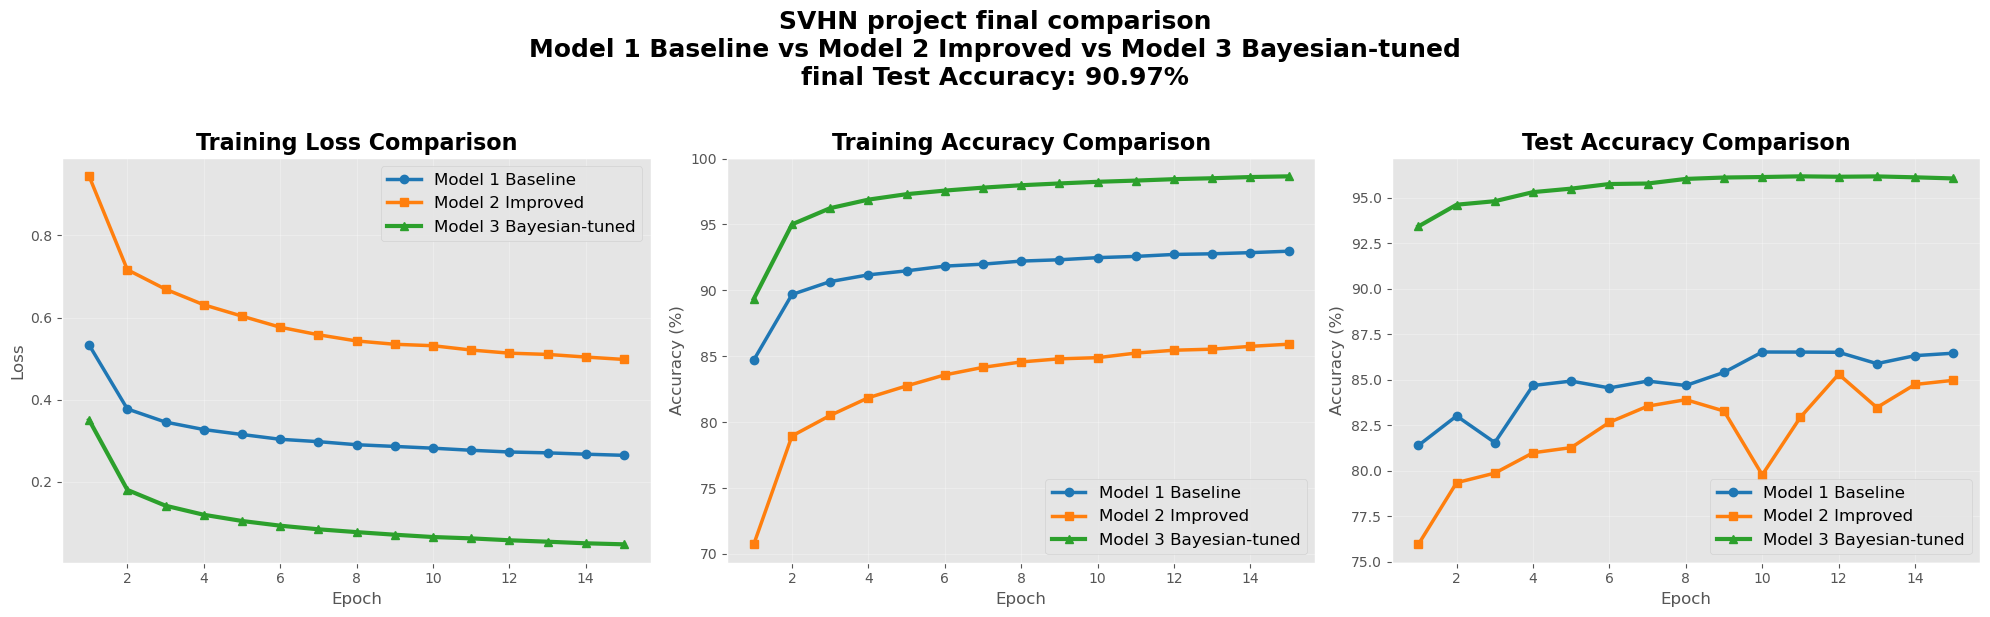

In [15]:
import matplotlib.pyplot as plt
from pathlib import Path

# ==================== 加载历史记录（直接调用你 demo 里的函数） ====================
SAVE_DIR = Path('saved_models')
history_path = SAVE_DIR / 'training_history.pkl'

if not history_path.exists():
    raise FileNotFoundError(" saved_models/training_history.pkl 不存在！请先保存历史记录")

with open(history_path, 'rb') as f:
    history = pickle.load(f)   # ← 使用你 demo 里的 pickle

print(f" 历史记录加载成功！（{history['metadata']['saved_date']} 保存）")
print(f"Epochs: {history['metadata']['epochs']}")

m1 = history['model1']
m2 = history['model2']
m3 = history['model3']          # ← 这里就是你的 Bayesian-tuned 模型

epochs = history['metadata']['epochs']

# ==================== 三图对比（Loss + Train Acc + Test Acc） ====================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Training Loss
ax = axes[0]
ax.plot(range(1, epochs+1), m1['train_loss'], 'o-', label='Model 1 Baseline', linewidth=2.5, color='#1f77b4')
ax.plot(range(1, epochs+1), m2['train_loss'], 's-', label='Model 2 Improved', linewidth=2.5, color='#ff7f0e')
ax.plot(range(1, epochs+1), m3['train_loss'], '^-', label='Model 3 Bayesian-tuned', linewidth=3, color='#2ca02c')
ax.set_title('Training Loss Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 2. Training Accuracy
ax = axes[1]
ax.plot(range(1, epochs+1), m1['train_acc'], 'o-', label='Model 1 Baseline', linewidth=2.5, color='#1f77b4')
ax.plot(range(1, epochs+1), m2['train_acc'], 's-', label='Model 2 Improved', linewidth=2.5, color='#ff7f0e')
ax.plot(range(1, epochs+1), m3['train_acc'], '^-', label='Model 3 Bayesian-tuned', linewidth=3, color='#2ca02c')
ax.set_title('Training Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# 3. Test Accuracy
ax = axes[2]
ax.plot(range(1, epochs+1), m1['test_acc'], 'o-', label='Model 1 Baseline', linewidth=2.5, color='#1f77b4')
ax.plot(range(1, epochs+1), m2['test_acc'], 's-', label='Model 2 Improved', linewidth=2.5, color='#ff7f0e')
ax.plot(range(1, epochs+1), m3['test_acc'], '^-', label='Model 3 Bayesian-tuned', linewidth=3, color='#2ca02c')
ax.set_title('Test Accuracy Comparison', fontsize=16, fontweight='bold')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

plt.suptitle('SVHN project final comparison\n'
             'Model 1 Baseline vs Model 2 Improved vs Model 3 Bayesian-tuned\n'
             f'final Test Accuracy: 90.97%', 
             fontsize=18, fontweight='bold', y=1.02)

plt.tight_layout()


# plt.savefig('SVHN_Model_Comparison_Curves.png', dpi=300, bbox_inches='tight')
# print(" 高清图片已保存为 SVHN_Model_Comparison_Curves.png（300 DPI）")
plt.show()